<a href="https://colab.research.google.com/github/danw1976/training-data/blob/main/fine_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install items

In [ ]:
import os
from datasets import load_dataset, Dataset, DatasetDict
from items import Item
import matplotlib.pyplot as plt

In [ ]:
# load dataset
dataset = load_dataset("Rohithqwerty/linux_data", split="train")
print(dataset)

Dataset({
    features: ['date', 'question_description', 'accepted_answer', 'question_title'],
    num_rows: 188126
})


In [ ]:
# Investigate
datapoint = dataset[1]
print(datapoint['question_title'])
print(datapoint['date'])
print(datapoint['question_description'])
print(datapoint['accepted_answer'])

How do keyboard input and text output work?
1402510190000000000

Suppose I press the A key in a text editor and this inserts the character a in the document and displays it on the screen. I know the editor application isn't directly communicating with the hardware (there's a kernel and stuff in between), so what is going on inside my computer?


There are several different scenarios; I'll describe the most common ones. The successive macroscopic events are:

Input: the key press event is transmitted from the keyboard hardware to the application.
Processing: the application decides that because the key A was pressed, it must display the character a.
Output: the application gives the order to display a on the screen.

GUI applications
The de facto standard graphical user interface of unix systems is the X Window System, often called X11 because it stabilized in the 11th version of its core protocol between applications and the display server. A program called the X server sits between th

In [ ]:
lengths = []
for datapoint in dataset:
    try:
      contents = datapoint['question_title'] + ' ' + datapoint['question_description'] + ' ' + datapoint['accepted_answer']
      lengths.append(len(contents.split()))
    except ValueError as e:
      pass

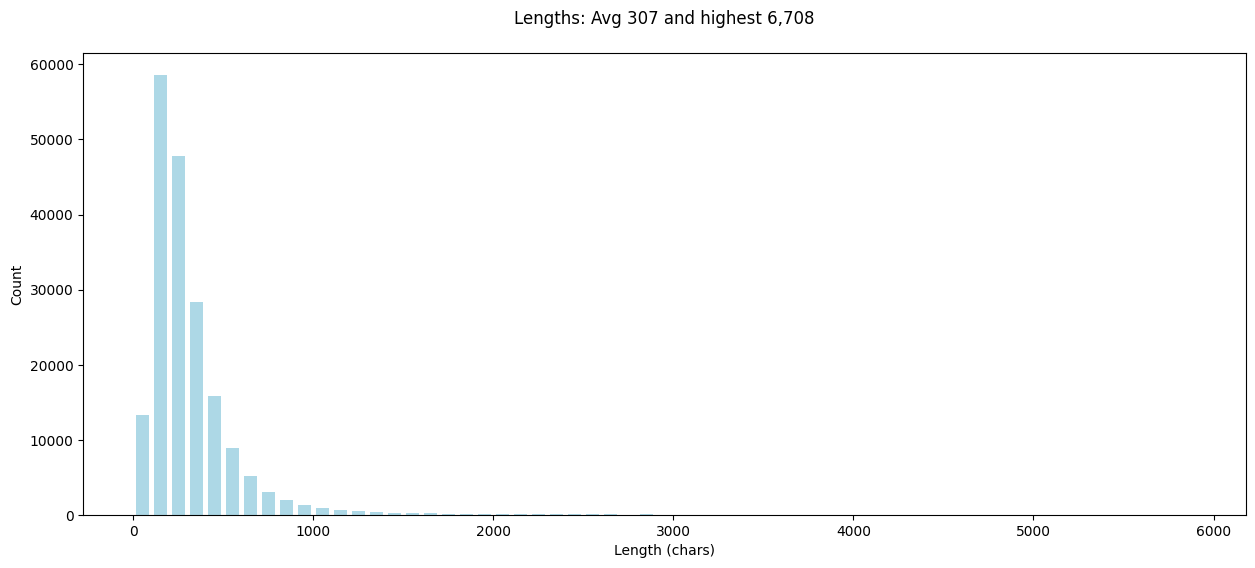

In [ ]:
# Plot the distribution of lengths
# to understand the max number of tokens to pass in when training open source model
# or cost with frontier model

plt.figure(figsize=(15, 6))
plt.title(f"Lengths: Avg {sum(lengths)/len(lengths):,.0f} and highest {max(lengths):,}\n")
plt.xlabel('Length (chars)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="lightblue", bins=range(0, 6000, 100))
plt.show()

In [ ]:
BASE_MODEL = "meta-llama/Meta-Llama-3.1.8B" # change to open source
MIN_TOKENS = 150
MAX_TOKENS = 1000
MIN_CHARS = 300
CEILING_CHARS = MAX_TOKENS * 7

class Item:
  """
  An Item is a curated datpoint of a question and answer.
  """

  tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

  title: str
  date: int
  question: str
  answer: str
  token_count: int = 0
  prompt: Optional[str] = None

  def __init__(self, data):
    self.title = data['question_title']
    self.parse(data)

  def parse(self, data):
    """
    Parse the datapoint and if it fits within the allowed Token range,
    then set include to True
    """
    contents = '\n'.join(data['question_description'])
    if contents:
      contents += '\n'
    answer = '\n'.join(data['accepted_answer'])
    if answer:
      contents += answer + '\n'
    if len(contents) > MIN_CHARS:
      contents = contents[:CEILING_CHARS]
      text = f"{self}"

